# GDP Final Model Leaderboard

This notebook builds a final, fair leaderboard for the main GDP models using the **common holdout test sample**.

Models included:
- OLS
- Ridge
- Elastic Net
- Random Forest
- XGBoost

Outputs created by this notebook:
- final ranked leaderboard across all models
- best model for each main specification
- best overall model
- algorithm-level summary
- best test-set yearly paths for presentation and reporting

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

METRICS_PATH = OUTPUT_DIR / "gdp_all_models_common_test_metrics.csv"
BEST_BY_SPEC_SOURCE_PATH = OUTPUT_DIR / "gdp_all_models_best_algorithm_by_spec.csv"
YEARLY_TEST_PATH = OUTPUT_DIR / "gdp_all_models_common_test_yearly_summary.csv"

metrics_df = pd.read_csv(METRICS_PATH)
best_by_spec_source_df = pd.read_csv(BEST_BY_SPEC_SOURCE_PATH)
yearly_test_df = pd.read_csv(YEARLY_TEST_PATH)

print("Metrics rows:", metrics_df.shape[0])
print("Best-by-spec rows:", best_by_spec_source_df.shape[0])
print("Yearly summary rows:", yearly_test_df.shape[0])

display(metrics_df)


Metrics rows: 15
Best-by-spec rows: 3
Yearly summary rows: 90


,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Model 1,OLS,813,"1,498.1181","3,477.1503",9.1617,0.9766
1,Model 1,Elastic Net,813,"1,512.4117","3,492.6625",9.2031,0.9763
2,Model 1,Ridge,813,"1,513.9324","3,494.8991",9.2067,0.9763
3,Model 1,XGBoost,813,"1,666.2786","3,878.7151",9.9957,0.9708
4,Model 1,Random Forest,813,"1,639.6849","4,010.1453",9.8598,0.9688
5,Model 2,Elastic Net,813,"1,486.9078","3,468.6213",9.1557,0.9767
6,Model 2,OLS,813,"1,485.0940","3,482.8558",9.0518,0.9765
7,Model 2,Ridge,813,"1,490.5958","3,483.9800",9.1480,0.9765
8,Model 2,Random Forest,813,"1,687.3212","4,027.8137",9.8958,0.9685
9,Model 2,XGBoost,813,"1,858.3525","4,168.2012",12.3253,0.9663


In [37]:
leaderboard_df = metrics_df.copy()
leaderboard_df["spec_number"] = leaderboard_df["spec"].str.extract(r"(\d+)").astype(int)

leaderboard_df["rank_mae"] = leaderboard_df["MAE"].rank(method="dense", ascending=True)
leaderboard_df["rank_rmse"] = leaderboard_df["RMSE"].rank(method="dense", ascending=True)
leaderboard_df["rank_mape"] = leaderboard_df["MAPE_pct"].rank(method="dense", ascending=True)
leaderboard_df["rank_r2"] = leaderboard_df["R_squared"].rank(method="dense", ascending=False)
leaderboard_df["rank_score"] = leaderboard_df[["rank_mae", "rank_rmse", "rank_mape", "rank_r2"]].sum(axis=1)

leaderboard_df = leaderboard_df.sort_values(
    ["rank_score", "RMSE", "MAPE_pct", "MAE", "R_squared", "spec_number", "algorithm"],
    ascending=[True, True, True, True, False, True, True]
).reset_index(drop=True)

best_overall_df = leaderboard_df.head(1).copy()

best_by_spec_df = (
    leaderboard_df.sort_values(
        ["spec_number", "RMSE", "MAPE_pct", "MAE", "R_squared", "rank_score"],
        ascending=[True, True, True, True, False, True]
    )
    .groupby("spec", group_keys=False)
    .head(1)
    .sort_values("spec_number")
    .reset_index(drop=True)
)

algorithm_summary_df = (
    leaderboard_df.groupby("algorithm", as_index=False)
    .agg(
        specs_covered=("spec", "nunique"),
        avg_MAE=("MAE", "mean"),
        avg_RMSE=("RMSE", "mean"),
        avg_MAPE_pct=("MAPE_pct", "mean"),
        avg_R_squared=("R_squared", "mean"),
        best_rank_score=("rank_score", "min")
    )
    .sort_values(["avg_RMSE", "avg_MAPE_pct", "avg_MAE", "avg_R_squared"], ascending=[True, True, True, False])
    .reset_index(drop=True)
)

best_by_spec_check_df = best_by_spec_df[["spec", "algorithm"]].merge(
    best_by_spec_source_df[["spec", "algorithm"]].rename(columns={"algorithm": "existing_best_algorithm"}),
    on="spec",
    how="left"
)
best_by_spec_check_df["matches_existing_file"] = (
    best_by_spec_check_df["algorithm"] == best_by_spec_check_df["existing_best_algorithm"]
)

rank_table_df = leaderboard_df[
    [
        "spec",
        "algorithm",
        "n_obs",
        "MAE",
        "RMSE",
        "MAPE_pct",
        "R_squared",
        "rank_mae",
        "rank_rmse",
        "rank_mape",
        "rank_r2",
        "rank_score"
    ]
].copy()

LEADERBOARD_OUT = OUTPUT_DIR / "gdp_final_model_leaderboard.csv"
BEST_BY_SPEC_OUT = OUTPUT_DIR / "gdp_final_model_best_by_spec.csv"
BEST_OVERALL_OUT = OUTPUT_DIR / "gdp_final_model_best_overall.csv"
ALGORITHM_SUMMARY_OUT = OUTPUT_DIR / "gdp_final_model_algorithm_summary.csv"
RANK_TABLE_OUT = OUTPUT_DIR / "gdp_final_model_metric_rank_table.csv"
BEST_BY_SPEC_CHECK_OUT = OUTPUT_DIR / "gdp_final_model_best_by_spec_check.csv"

leaderboard_df.to_csv(LEADERBOARD_OUT, index=False)
best_by_spec_df.to_csv(BEST_BY_SPEC_OUT, index=False)
best_overall_df.to_csv(BEST_OVERALL_OUT, index=False)
algorithm_summary_df.to_csv(ALGORITHM_SUMMARY_OUT, index=False)
rank_table_df.to_csv(RANK_TABLE_OUT, index=False)
best_by_spec_check_df.to_csv(BEST_BY_SPEC_CHECK_OUT, index=False)

print("Saved:")
print("-", LEADERBOARD_OUT)
print("-", BEST_BY_SPEC_OUT)
print("-", BEST_OVERALL_OUT)
print("-", ALGORITHM_SUMMARY_OUT)
print("-", RANK_TABLE_OUT)
print("-", BEST_BY_SPEC_CHECK_OUT)


Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_leaderboard.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_best_by_spec.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_best_overall.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_algorithm_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_metric_rank_table.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_best_by_spec_check.csv


In [38]:
print("Best overall model:")
display(best_overall_df)

print("Best model for each main specification:")
display(best_by_spec_df)

print("Algorithm-level average performance:")
display(algorithm_summary_df)

print("Check against the existing best-by-spec file:")
display(best_by_spec_check_df)

print("Full ranked leaderboard:")
display(rank_table_df)


Best overall model:


,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared,spec_number,rank_mae,rank_rmse,rank_mape,rank_r2,rank_score
0,Model 3,OLS,813,"1,468.1942","3,472.9950",8.8964,0.9766,3,1.0000,2.0000,1.0000,2.0000,6.0000


Best model for each main specification:


,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared,spec_number,rank_mae,rank_rmse,rank_mape,rank_r2,rank_score
0,Model 1,OLS,813,"1,498.1181","3,477.1503",9.1617,0.9766,1,6.0000,5.0000,6.0000,2.0000,19.0000
1,Model 2,Elastic Net,813,"1,486.9078","3,468.6213",9.1557,0.9767,2,3.0000,1.0000,5.0000,1.0000,10.0000
2,Model 3,OLS,813,"1,468.1942","3,472.9950",8.8964,0.9766,3,1.0000,2.0000,1.0000,2.0000,6.0000


Algorithm-level average performance:


,algorithm,specs_covered,avg_MAE,avg_RMSE,avg_MAPE_pct,avg_R_squared,best_rank_score
0,OLS,3,"1,483.8021","3,477.6670",9.0366,0.9766,6.0000
1,Elastic Net,3,"1,495.7265","3,479.1883",9.1666,0.9765,10.0000
2,Ridge,3,"1,490.9075","3,483.9581",9.0837,0.9765,7.0000
3,Random Forest,3,"1,660.2220","4,001.4655",9.7474,0.9689,36.0000
4,XGBoost,3,"1,770.4708","4,125.9882",10.9618,0.9669,38.0000


Check against the existing best-by-spec file:


,spec,algorithm,existing_best_algorithm,matches_existing_file
0,Model 1,OLS,OLS,True
1,Model 2,Elastic Net,Elastic Net,True
2,Model 3,OLS,OLS,True


Full ranked leaderboard:


,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared,rank_mae,rank_rmse,rank_mape,rank_r2,rank_score
0,Model 3,OLS,813,"1,468.1942","3,472.9950",8.8964,0.9766,1.0000,2.0000,1.0000,2.0000,6.0000
1,Model 3,Ridge,813,"1,468.1942","3,472.9951",8.8964,0.9766,1.0000,3.0000,1.0000,2.0000,7.0000
2,Model 2,Elastic Net,813,"1,486.9078","3,468.6213",9.1557,0.9767,3.0000,1.0000,5.0000,1.0000,10.0000
3,Model 3,Elastic Net,813,"1,487.8599","3,476.2812",9.1411,0.9766,4.0000,4.0000,3.0000,2.0000,13.0000
4,Model 2,OLS,813,"1,485.0940","3,482.8558",9.0518,0.9765,2.0000,6.0000,2.0000,3.0000,13.0000
5,Model 1,OLS,813,"1,498.1181","3,477.1503",9.1617,0.9766,6.0000,5.0000,6.0000,2.0000,19.0000
6,Model 2,Ridge,813,"1,490.5958","3,483.9800",9.1480,0.9765,5.0000,7.0000,4.0000,3.0000,19.0000
7,Model 1,Elastic Net,813,"1,512.4117","3,492.6625",9.2031,0.9763,7.0000,8.0000,7.0000,4.0000,26.0000
8,Model 1,Ridge,813,"1,513.9324","3,494.8991",9.2067,0.9763,8.0000,9.0000,8.0000,4.0000,29.0000
9,Model 3,Random Forest,813,"1,653.6599","3,966.4374",9.4865,0.9695,10.0000,11.0000,9.0000,6.0000,36.0000


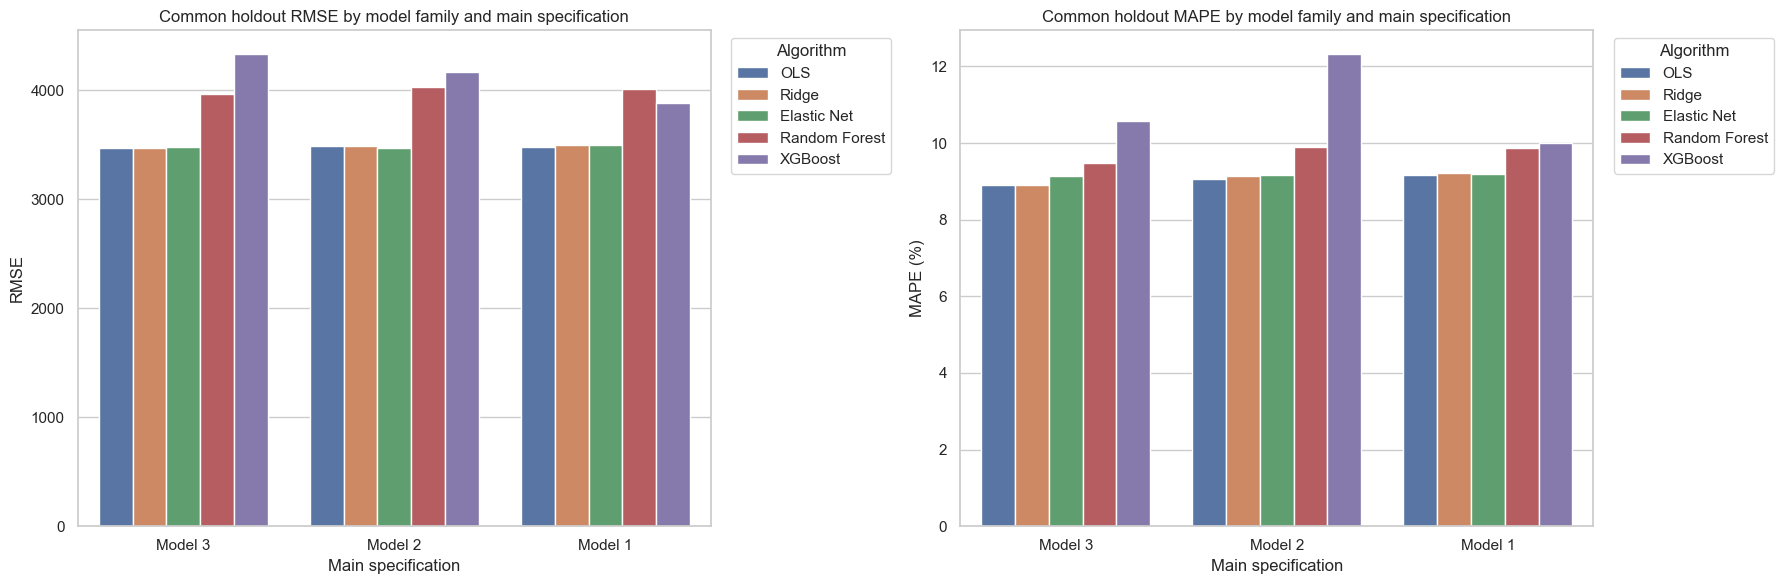

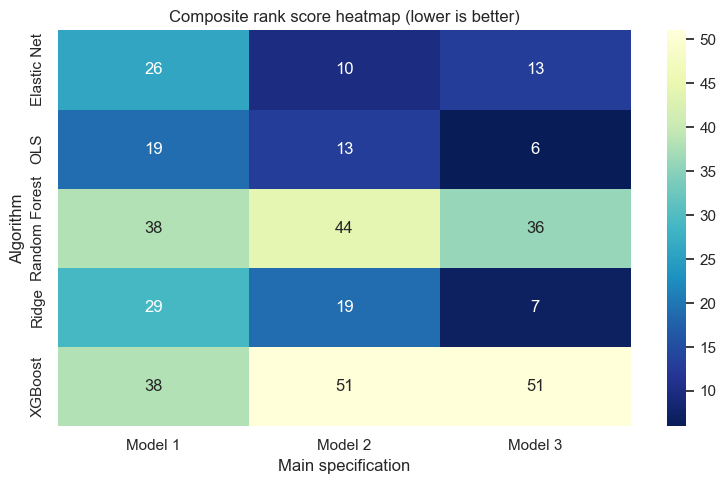

In [39]:
plot_df = leaderboard_df.copy()
plot_df["spec_algorithm"] = plot_df["spec"] + " | " + plot_df["algorithm"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=plot_df,
    x="spec",
    y="RMSE",
    hue="algorithm",
    ax=axes[0]
)
axes[0].set_title("Common holdout RMSE by model family and main specification")
axes[0].set_xlabel("Main specification")
axes[0].set_ylabel("RMSE")
axes[0].legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(
    data=plot_df,
    x="spec",
    y="MAPE_pct",
    hue="algorithm",
    ax=axes[1]
)
axes[1].set_title("Common holdout MAPE by model family and main specification")
axes[1].set_xlabel("Main specification")
axes[1].set_ylabel("MAPE (%)")
axes[1].legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

heatmap_df = rank_table_df.pivot(index="algorithm", columns="spec", values="rank_score")
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu_r", fmt=".0f")
plt.title("Composite rank score heatmap (lower is better)")
plt.xlabel("Main specification")
plt.ylabel("Algorithm")
plt.tight_layout()
plt.show()


Saved: /Users/tonytony/Final Project/Data/Cleaned/gdp_final_model_best_test_yearly_paths.csv


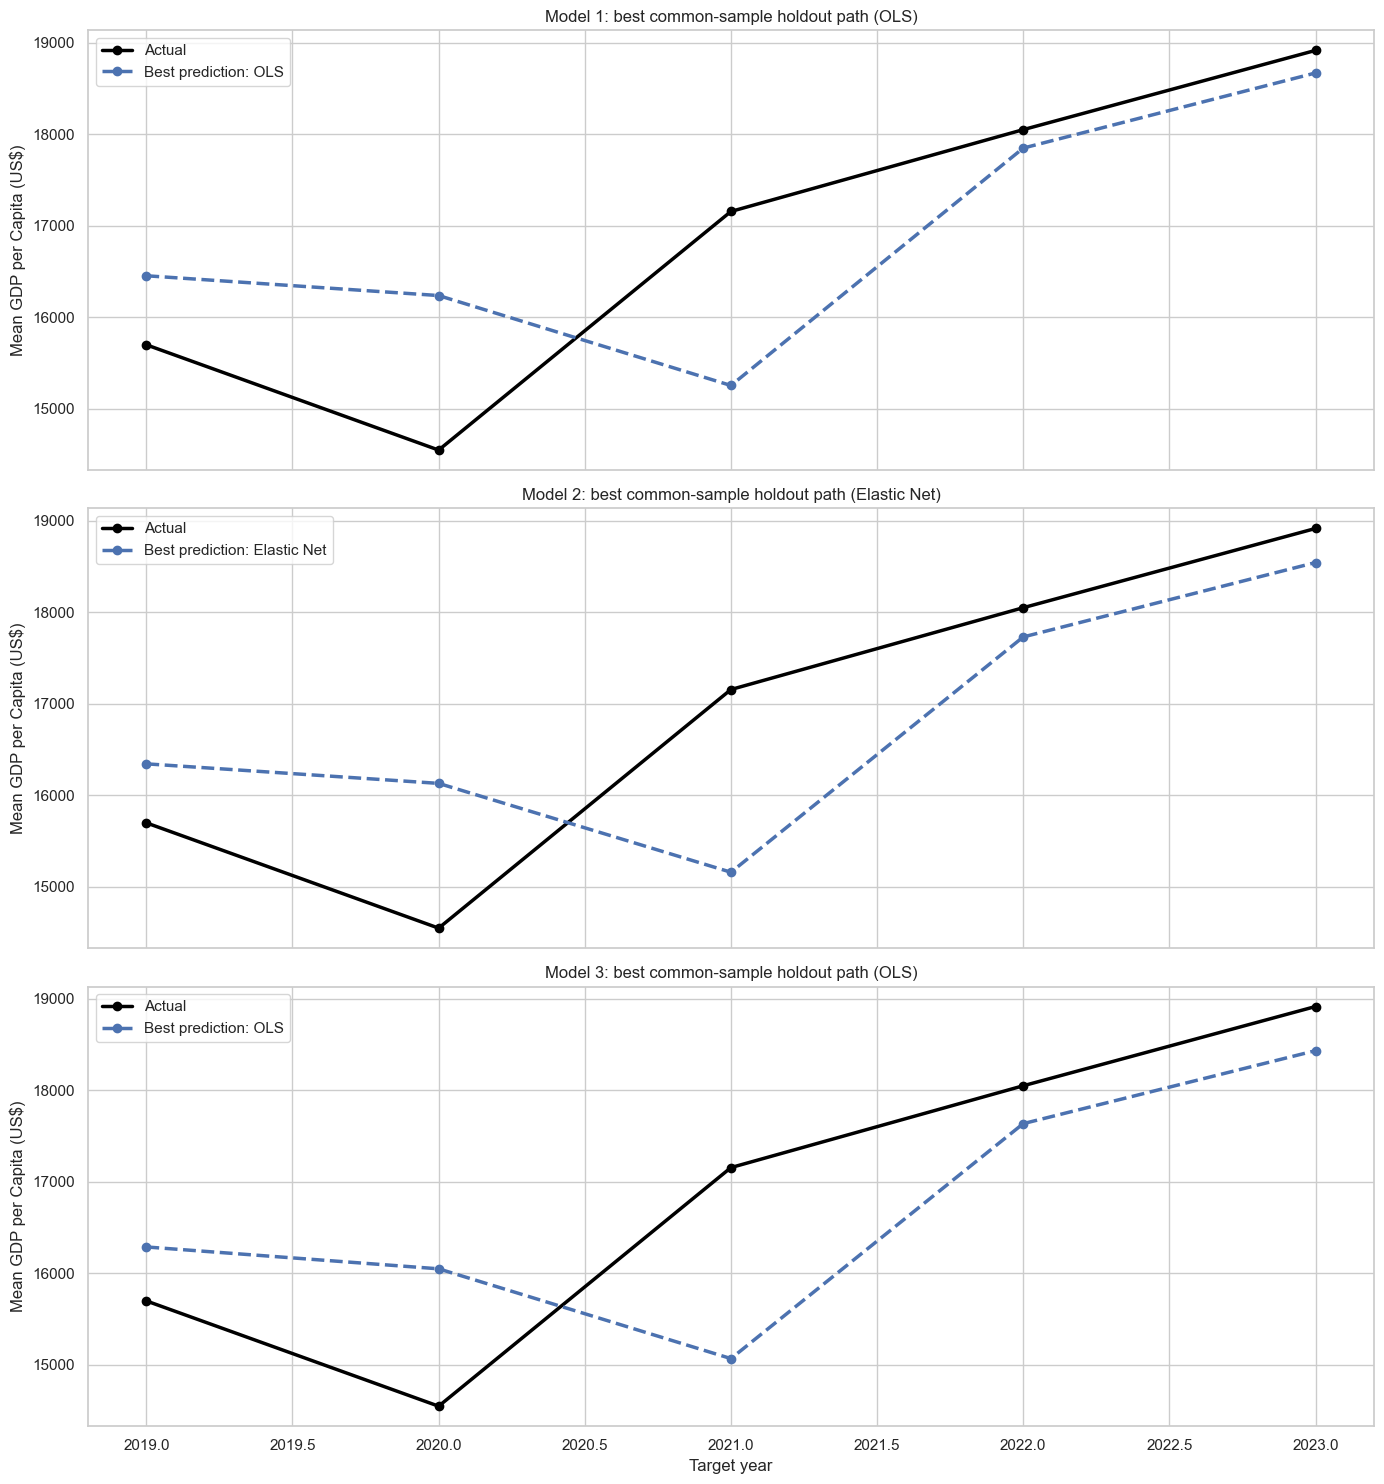

,spec,algorithm,target_year,mean_gdp
0,Model 1,OLS,2019,"16,452.9427"
1,Model 1,OLS,2020,"16,236.8379"
2,Model 1,OLS,2021,"15,254.6461"
3,Model 1,OLS,2022,"17,847.2108"
4,Model 1,OLS,2023,"18,667.7446"


In [40]:
best_test_yearly_df = yearly_test_df.merge(
    best_by_spec_df[["spec", "algorithm"]],
    on=["spec", "algorithm"],
    how="inner"
)

BEST_TEST_YEARLY_OUT = OUTPUT_DIR / "gdp_final_model_best_test_yearly_paths.csv"
best_test_yearly_df.to_csv(BEST_TEST_YEARLY_OUT, index=False)
print("Saved:", BEST_TEST_YEARLY_OUT)

spec_order = sorted(best_by_spec_df["spec"].tolist(), key=lambda x: int(x.split()[-1]))
fig, axes = plt.subplots(len(spec_order), 1, figsize=(14, 5 * len(spec_order)), sharex=True)

if len(spec_order) == 1:
    axes = [axes]

for ax, spec_label in zip(axes, spec_order):
    actual_spec = yearly_test_df[
        (yearly_test_df["spec"] == spec_label) & (yearly_test_df["algorithm"] == "Actual")
    ].sort_values("target_year")

    best_row = best_by_spec_df[best_by_spec_df["spec"] == spec_label].iloc[0]
    pred_spec = best_test_yearly_df[
        (best_test_yearly_df["spec"] == spec_label) &
        (best_test_yearly_df["algorithm"] == best_row["algorithm"])
    ].sort_values("target_year")

    ax.plot(
        actual_spec["target_year"],
        actual_spec["mean_gdp"],
        marker="o",
        linewidth=2.5,
        color="black",
        label="Actual"
    )
    ax.plot(
        pred_spec["target_year"],
        pred_spec["mean_gdp"],
        marker="o",
        linestyle="--",
        linewidth=2.5,
        label=f"Best prediction: {best_row['algorithm']}"
    )

    ax.set_title(
        f"{spec_label}: best common-sample holdout path ({best_row['algorithm']})"
    )
    ax.set_ylabel("Mean GDP per Capita (US$)")
    ax.legend()

axes[-1].set_xlabel("Target year")
plt.tight_layout()
plt.show()

display(best_test_yearly_df.head())


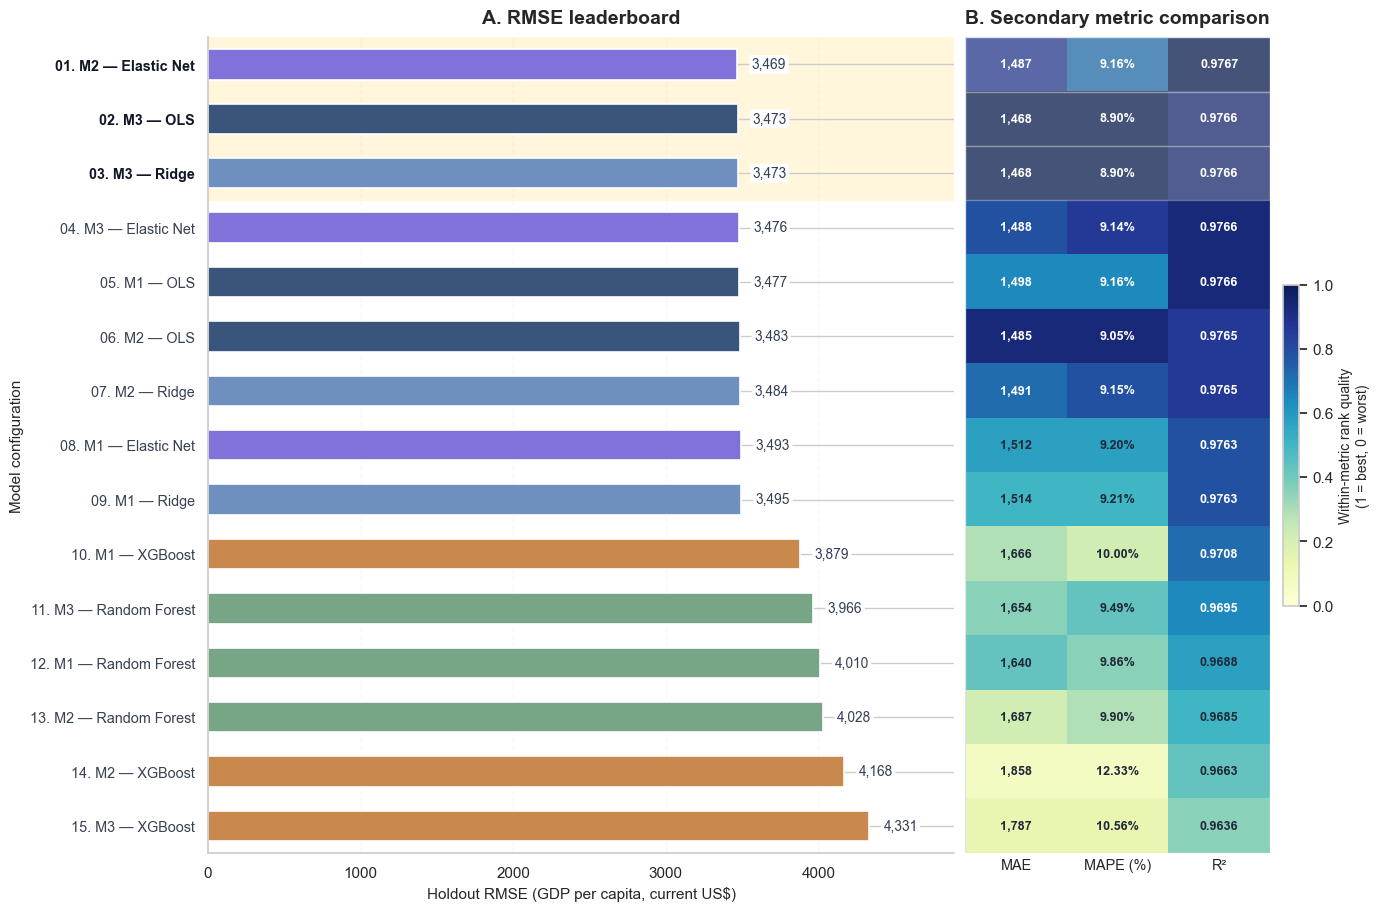

Saved: /Users/tonytony/Final Project/output/figures/figure_6_1_gdp_benchmark_two_panel_v3_2.png


,overall_rank,spec,algorithm,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,1,Model 2,Elastic Net,813,"1,486.9078","3,468.6213",9.1557,0.9767
1,2,Model 3,OLS,813,"1,468.1942","3,472.9950",8.8964,0.9766
2,3,Model 3,Ridge,813,"1,468.1942","3,472.9951",8.8964,0.9766
3,4,Model 3,Elastic Net,813,"1,487.8599","3,476.2812",9.1411,0.9766
4,5,Model 1,OLS,813,"1,498.1181","3,477.1503",9.1617,0.9766
5,6,Model 2,OLS,813,"1,485.0940","3,482.8558",9.0518,0.9765
6,7,Model 2,Ridge,813,"1,490.5958","3,483.9800",9.1480,0.9765
7,8,Model 1,Elastic Net,813,"1,512.4117","3,492.6625",9.2031,0.9763
8,9,Model 1,Ridge,813,"1,513.9324","3,494.8991",9.2067,0.9763
9,10,Model 1,XGBoost,813,"1,666.2786","3,878.7151",9.9957,0.9708


In [41]:
# Figure 6.1 — Version 3.2
# Clean PDF/report version
# Left panel: bars + labels only (no end dots)
# Right panel: clean heatmap with aligned rows
# Assumes leaderboard_df already exists in memory

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.patches import Rectangle

OUTPUT_DIR = Path("/Users/tonytony/Final Project/output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# 1. Prepare ranked dataframe
# -------------------------------------------------
plot_df = leaderboard_df.copy()

plot_df["spec_number"] = plot_df["spec"].str.extract(r"(\d+)").astype(int)
plot_df["algorithm_display"] = plot_df["algorithm"].replace({
    "OLS": "OLS",
    "Ridge": "Ridge",
    "Elastic Net": "Elastic Net",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost",
})

plot_df = plot_df.sort_values(
    ["RMSE", "MAPE_pct", "MAE", "R_squared", "spec_number", "algorithm_display"],
    ascending=[True, True, True, False, True, True]
).reset_index(drop=True)

plot_df["overall_rank"] = np.arange(1, len(plot_df) + 1)
plot_df["config_label"] = plot_df.apply(
    lambda row: f"{int(row['overall_rank']):02d}. M{int(row['spec_number'])} — {row['algorithm_display']}",
    axis=1
)

algo_palette = {
    "OLS": "#39557B",
    "Ridge": "#6F8FBE",
    "Elastic Net": "#7F72D8",
    "Random Forest": "#77A585",
    "XGBoost": "#C9894D",
}
plot_df["bar_color"] = plot_df["algorithm_display"].map(algo_palette)

n_rows = len(plot_df)
y_pos = np.arange(n_rows)

# -------------------------------------------------
# 2. Secondary metric matrix
# -------------------------------------------------
metric_labels = ["MAE", "MAPE (%)", "R²"]

metric_rank_quality = np.column_stack([
    1 - ((plot_df["MAE"].rank(method="dense", ascending=True) - 1) / (n_rows - 1)),
    1 - ((plot_df["MAPE_pct"].rank(method="dense", ascending=True) - 1) / (n_rows - 1)),
    1 - ((plot_df["R_squared"].rank(method="dense", ascending=False) - 1) / (n_rows - 1)),
])

annot_matrix = np.column_stack([
    plot_df["MAE"].map(lambda x: f"{x:,.0f}").to_numpy(),
    plot_df["MAPE_pct"].map(lambda x: f"{x:.2f}%").to_numpy(),
    plot_df["R_squared"].map(lambda x: f"{x:.4f}").to_numpy(),
])

# -------------------------------------------------
# 3. Figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(17.6, 10.2))
gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[2.68, 1.20],
    wspace=0.02
)

ax_rmse = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[0, 1])

# -------------------------------------------------
# 4. Highlight only top 3 rows
# -------------------------------------------------
for idx in range(3):
    ax_rmse.axhspan(idx - 0.5, idx + 0.5, color="#FFF6DC", zorder=0)
    ax_heat.axhspan(idx - 0.5, idx + 0.5, color="#FFF6DC", alpha=0.25, zorder=2)

# -------------------------------------------------
# 5. Panel A — RMSE bars only
# -------------------------------------------------
bar_height = 0.56
xmax = plot_df["RMSE"].max()
rmse_label_offset = max(xmax * 0.022, 90)
x_padding = max(xmax * 0.12, 560)

ax_rmse.barh(
    y_pos,
    plot_df["RMSE"],
    height=bar_height,
    color=plot_df["bar_color"],
    edgecolor="white",
    linewidth=1.2,
    zorder=2
)

# clean RMSE labels with white mask behind text
for y, rmse_val in zip(y_pos, plot_df["RMSE"]):
    ax_rmse.text(
        rmse_val + rmse_label_offset,
        y,
        f"{rmse_val:,.0f}",
        ha="left",
        va="center",
        fontsize=9.9,
        color="#334155",
        bbox=dict(
            boxstyle="round,pad=0.18,rounding_size=0.10",
            facecolor="white",
            edgecolor="none",
            alpha=0.99
        ),
        zorder=5
    )

ax_rmse.set_yticks(y_pos)
ax_rmse.set_yticklabels(plot_df["config_label"], fontsize=10.4)
ax_rmse.set_ylim(n_rows - 0.5, -0.5)
ax_rmse.set_xlim(0, xmax + x_padding)

for idx, tick in enumerate(ax_rmse.get_yticklabels()):
    if idx < 3:
        tick.set_fontweight("bold")
        tick.set_color("#111827")
    else:
        tick.set_color("#374151")

ax_rmse.set_xlabel("Holdout RMSE (GDP per capita, current US$)", fontsize=11)
ax_rmse.set_ylabel("Model configuration", fontsize=11)
ax_rmse.set_title("A. RMSE leaderboard", fontsize=14, fontweight="bold", pad=10)

# vertical guide only
ax_rmse.grid(axis="x", linestyle="--", alpha=0.15)
ax_rmse.set_axisbelow(True)

for spine in ["top", "right"]:
    ax_rmse.spines[spine].set_visible(False)

# -------------------------------------------------
# 6. Panel B — clean aligned heatmap
# -------------------------------------------------
heat_cmap = plt.colormaps["YlGnBu"]
norm = Normalize(vmin=0, vmax=1)

im = ax_heat.imshow(
    metric_rank_quality,
    cmap=heat_cmap,
    norm=norm,
    aspect="auto",
    interpolation="nearest",
    origin="upper",
    extent=(-0.5, len(metric_labels) - 0.5, n_rows - 0.5, -0.5),
    zorder=1
)

# annotate values only
for i in range(n_rows):
    for j in range(len(metric_labels)):
        quality = metric_rank_quality[i, j]
        txt_color = "white" if quality >= 0.58 else "#1F2937"
        ax_heat.text(
            j,
            i,
            annot_matrix[i, j],
            ha="center",
            va="center",
            fontsize=9.1,
            color=txt_color,
            fontweight="semibold",
            zorder=3
        )

# outer border only
ax_heat.add_patch(
    Rectangle(
        (-0.5, -0.5),
        width=len(metric_labels),
        height=n_rows,
        fill=False,
        linewidth=0.9,
        edgecolor="#DBE4EE",
        zorder=4
    )
)

ax_heat.set_xlim(-0.5, len(metric_labels) - 0.5)
ax_heat.set_ylim(n_rows - 0.5, -0.5)

ax_heat.set_xticks(np.arange(len(metric_labels)))
ax_heat.set_xticklabels(metric_labels, fontsize=10.4)

ax_heat.set_yticks(y_pos)
ax_heat.set_yticklabels([""] * n_rows)

ax_heat.set_title("B. Secondary metric comparison", fontsize=14, fontweight="bold", pad=10)

ax_heat.tick_params(axis="x", length=0)
ax_heat.tick_params(axis="y", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax_heat.spines[spine].set_visible(False)


# -------------------------------------------------
# 8. Colorbar
# -------------------------------------------------
cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=heat_cmap),
    ax=ax_heat,
    fraction=0.048,
    pad=0.04
)
cbar.set_label(
    "Within-metric rank quality\n(1 = best, 0 = worst)",
    fontsize=10
)

# -------------------------------------------------
# 9. Save + show
# -------------------------------------------------
save_path = OUTPUT_DIR / "figure_6_1_gdp_benchmark_two_panel_v3_2.png"

plt.subplots_adjust(
    left=0.31,
    right=0.93,
    top=0.88,
    bottom=0.08,
    wspace=0.02
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

display(
    plot_df[
        ["overall_rank", "spec", "algorithm", "n_obs", "MAE", "RMSE", "MAPE_pct", "R_squared"]
    ]
)

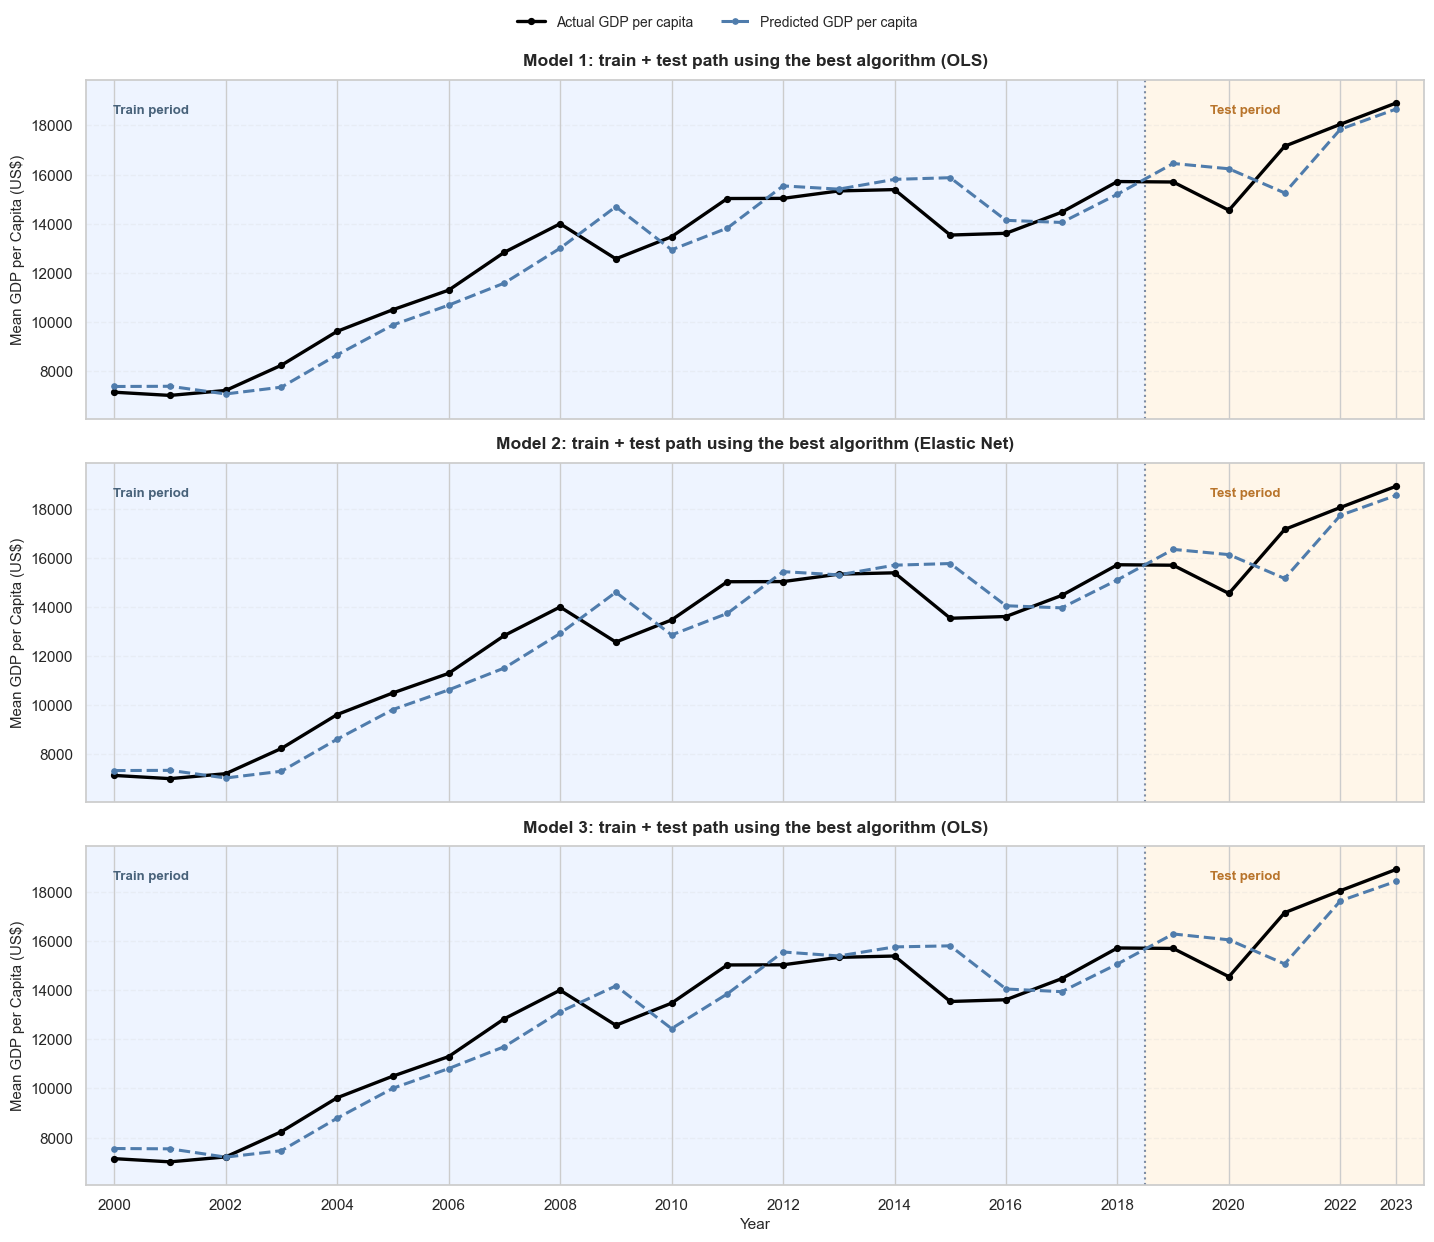

Saved: /Users/tonytony/Final Project/output/figures/figure_6_2_best_by_spec_train_test_paths.png


,spec,spec_label,algorithm,MAE,RMSE,MAPE_pct,R_squared
0,Model 1,Model 1,OLS,"1,498.1181","3,477.1503",9.1617,0.9766
1,Model 2,Model 2,Elastic Net,"1,486.9078","3,468.6213",9.1557,0.9767
2,Model 3,Model 3,OLS,"1,468.1942","3,472.9950",8.8964,0.9766


In [45]:
# Figure 6.2 — Train + test paths for the best algorithm within each main GDP specification
# Replace the old Figure 6.2 cell with this full version

from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA_DIR = Path("/Users/tonytony/Final Project/Data/Cleaned")
OUTPUT_DIR = Path("/Users/tonytony/Final Project/output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_path_candidates = [
    DATA_DIR / "gdp_final_model_best_by_spec.csv",
    DATA_DIR / "gdp_final_model_best_by_spec_check.csv",
    DATA_DIR / "gdp_all_models_best_algorithm_by_spec.csv",
]

best_path = None
for candidate in best_path_candidates:
    if candidate.exists():
        best_path = candidate
        break

if best_path is None:
    raise FileNotFoundError("Cannot find a best-by-spec summary file in Data/Cleaned.")

context_path = DATA_DIR / "gdp_all_models_train_test_context_yearly_summary.csv"
if not context_path.exists():
    raise FileNotFoundError(f"Missing context file: {context_path}")

best_by_spec_df = pd.read_csv(best_path)
context_df = pd.read_csv(context_path)

# ----------------------------
# Clean and validate inputs
# ----------------------------
best_by_spec_df.columns = [str(col).strip() for col in best_by_spec_df.columns]
context_df.columns = [str(col).strip() for col in context_df.columns]

if "plot_year" not in context_df.columns:
    if "year" in context_df.columns:
        context_df = context_df.rename(columns={"year": "plot_year"})
    else:
        raise KeyError("Context file must contain either 'plot_year' or 'year'.")

required_best_cols = {"spec", "algorithm"}
required_context_cols = {"spec", "algorithm", "plot_year", "mean_gdp", "segment"}

missing_best = required_best_cols - set(best_by_spec_df.columns)
missing_context = required_context_cols - set(context_df.columns)

if missing_best:
    raise KeyError(f"Best-by-spec file is missing columns: {missing_best}")
if missing_context:
    raise KeyError(f"Context file is missing columns: {missing_context}")

best_by_spec_df["spec"] = best_by_spec_df["spec"].astype(str).str.strip()
best_by_spec_df["algorithm"] = best_by_spec_df["algorithm"].astype(str).str.strip()

context_df["spec"] = context_df["spec"].astype(str).str.strip()
context_df["algorithm"] = context_df["algorithm"].astype(str).str.strip()
context_df["segment"] = context_df["segment"].astype(str).str.strip().str.lower()

context_df["plot_year"] = pd.to_numeric(context_df["plot_year"], errors="coerce")
context_df["mean_gdp"] = pd.to_numeric(context_df["mean_gdp"], errors="coerce")
context_df = context_df.dropna(subset=["plot_year", "mean_gdp"]).copy()
context_df["plot_year"] = context_df["plot_year"].astype(int)

for metric_col in ["MAE", "RMSE", "MAPE_pct", "R_squared"]:
    if metric_col in best_by_spec_df.columns:
        best_by_spec_df[metric_col] = pd.to_numeric(best_by_spec_df[metric_col], errors="coerce")

# ----------------------------
# Helper functions
# ----------------------------
def extract_spec_number(spec_value):
    match = re.search(r"(\d+)", str(spec_value))
    return int(match.group(1)) if match else 999

def build_spec_label(spec_value):
    num = extract_spec_number(spec_value)
    return f"Model {num}" if num != 999 else str(spec_value)

best_by_spec_df["spec_label"] = best_by_spec_df["spec"].apply(build_spec_label)
best_by_spec_df = (
    best_by_spec_df.sort_values("spec", key=lambda s: s.map(extract_spec_number))
    .drop_duplicates(subset=["spec"], keep="first")
    .copy()
)

spec_order = best_by_spec_df["spec"].tolist()
best_algo_map = dict(zip(best_by_spec_df["spec"], best_by_spec_df["algorithm"]))
spec_label_map = dict(zip(best_by_spec_df["spec"], best_by_spec_df["spec_label"]))

# ----------------------------
# Figure-wide limits and ranges
# ----------------------------
train_mask = context_df["segment"].str.contains("train", na=False)
test_mask = context_df["segment"].str.contains("test", na=False)

if not train_mask.any() or not test_mask.any():
    raise ValueError("Context file must contain both train and test segments.")

train_end_year = int(context_df.loc[train_mask, "plot_year"].max())
test_start_year = int(context_df.loc[test_mask, "plot_year"].min())
x_min = int(context_df["plot_year"].min())
x_max = int(context_df["plot_year"].max())

all_values = []
for spec in spec_order:
    algo = best_algo_map[spec]
    spec_slice = context_df[
        (context_df["spec"] == spec)
        & (context_df["algorithm"].str.lower().isin(["actual", algo.lower()]))
    ].copy()
    all_values.extend(spec_slice["mean_gdp"].tolist())

y_min = min(all_values)
y_max = max(all_values)
y_pad = max((y_max - y_min) * 0.08, 250)

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(
    len(spec_order),
    1,
    figsize=(14.5, 4.4 * len(spec_order)),
    sharex=True,
    sharey=True
)

if len(spec_order) == 1:
    axes = [axes]

legend_handles = [
    Line2D([0], [0], color="black", linewidth=2.4, marker="o", markersize=4.2, label="Actual GDP per capita"),
    Line2D([0], [0], color="#4f7cac", linewidth=2.2, linestyle="--", marker="o", markersize=3.8, label="Predicted GDP per capita"),
]

for ax, spec in zip(axes, spec_order):
    best_algo = best_algo_map[spec]
    spec_label = spec_label_map[spec]

    actual_spec = context_df[
        (context_df["spec"] == spec)
        & (context_df["algorithm"].str.lower() == "actual")
    ].sort_values("plot_year").copy()

    pred_spec = context_df[
        (context_df["spec"] == spec)
        & (context_df["algorithm"].str.lower() == best_algo.lower())
    ].sort_values("plot_year").copy()

    ax.axvspan(
        x_min - 0.5,
        train_end_year + 0.5,
        color="#eef4ff",
        alpha=0.95,
        zorder=0
    )
    ax.axvspan(
        test_start_year - 0.5,
        x_max + 0.5,
        color="#fff6e8",
        alpha=0.95,
        zorder=0
    )
    ax.axvline(
        test_start_year - 0.5,
        color="#7d8ca3",
        linestyle=":",
        linewidth=1.5,
        zorder=1
    )

    ax.plot(
        actual_spec["plot_year"],
        actual_spec["mean_gdp"],
        color="black",
        linewidth=2.4,
        marker="o",
        markersize=4.2,
        zorder=3
    )
    ax.plot(
        pred_spec["plot_year"],
        pred_spec["mean_gdp"],
        color="#4f7cac",
        linewidth=2.2,
        linestyle="--",
        marker="o",
        markersize=3.8,
        zorder=3
    )

    ax.set_title(
        f"{spec_label}: train + test path using the best algorithm ({best_algo})",
        fontsize=12.5,
        fontweight="bold",
        pad=10
    )
    ax.set_ylabel("Mean GDP per Capita (US$)", fontsize=10.8)
    ax.set_xlim(x_min - 0.5, x_max + 0.5)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)
    ax.grid(axis="y", linestyle="--", alpha=0.20)

    ax.text(
        0.02,
        0.90,
        "Train period",
        transform=ax.transAxes,
        fontsize=9.5,
        color="#48627a",
        fontweight="bold"
    )
    ax.text(
        0.84,
        0.90,
        "Test period",
        transform=ax.transAxes,
        fontsize=9.5,
        color="#b8742b",
        fontweight="bold"
    )

# x-axis ticks as clean integer years
year_ticks = list(range(x_min, x_max + 1, 2))
if x_max not in year_ticks:
    year_ticks.append(x_max)
year_ticks = sorted(set(year_ticks))

for ax in axes:
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(y) for y in year_ticks])

axes[-1].set_xlabel("Year", fontsize=11)


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=2,
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

save_path = OUTPUT_DIR / "figure_6_2_best_by_spec_train_test_paths.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

summary_cols = [col for col in ["spec", "spec_label", "algorithm", "MAE", "RMSE", "MAPE_pct", "R_squared"] if col in best_by_spec_df.columns]
display(best_by_spec_df[summary_cols].round(4))

Available models: ['Model 1 – Baseline', 'Model 2 – Extended', 'Model 3 – Full Forecasting']
Rows selected for Figure 6.3: 14


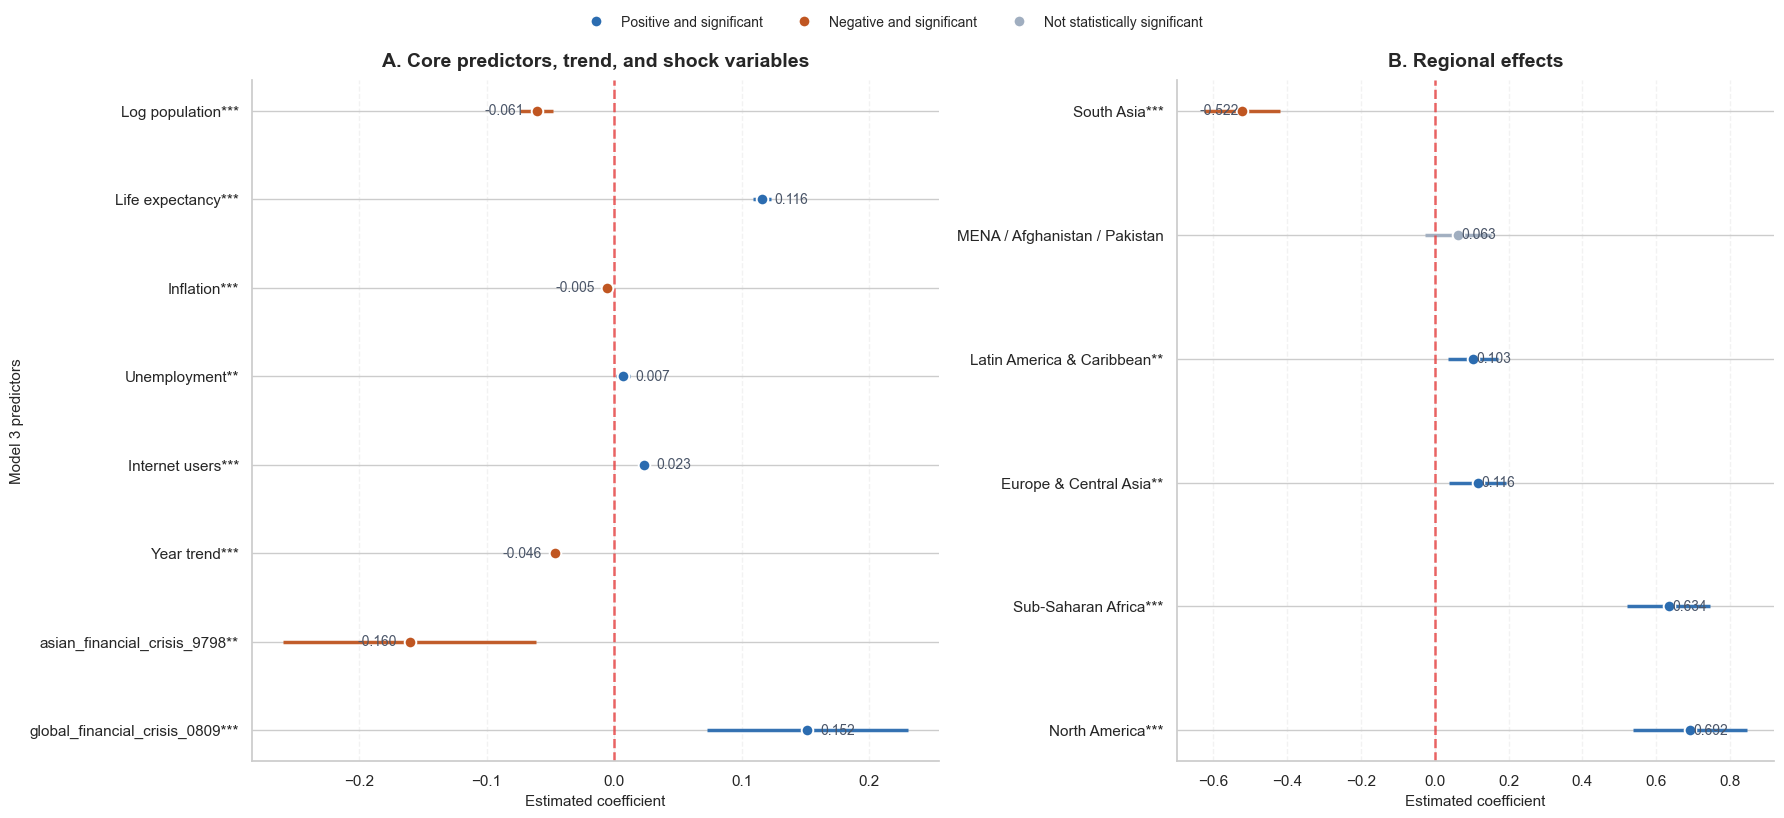

Saved: /Users/tonytony/Final Project/output/figures/figure_6_3_model_3_coefficients_v2.png


,term_label,coefficient,ci_lower,ci_upper,p_value
10,Europe & Central Asia,0.1157,0.0378,0.1936,0.0036
11,Latin America & Caribbean,0.1028,0.0353,0.1704,0.0029
12,MENA / Afghanistan / Pakistan,0.0629,-0.0269,0.1528,0.1700
13,North America,0.6918,0.5379,0.8456,0.0000
14,South Asia,-0.5223,-0.6254,-0.4191,0.0000
15,Sub-Saharan Africa,0.6337,0.5218,0.7457,0.0000
16,Log population,-0.0607,-0.0735,-0.0479,0.0000
17,Life expectancy,0.1160,0.1087,0.1232,0.0000
18,Inflation,-0.0053,-0.0067,-0.0039,0.0000
19,Unemployment,0.0070,0.0018,0.0122,0.0079


In [47]:
# Figure 6.3 — Version 2
# Two-panel coefficient plot for Model 3 - Full Forecasting

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BASE_DIR = Path("/Users/tonytony/Final Project")
COEF_PATH = BASE_DIR / "Data" / "Cleaned" / "gdp_main_models_coefficients.csv"
OUTPUT_DIR = BASE_DIR / "output" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

coef_df = pd.read_csv(COEF_PATH)

# Show available models in the same style as the old cell
model_name_map = {
    "Model 1 - Baseline": "Model 1 – Baseline",
    "Model 2 - Extended": "Model 2 – Extended",
    "Model 3 - Full Forecasting": "Model 3 – Full Forecasting",
}
available_models = [
    model_name_map.get(x, x)
    for x in coef_df["model"].dropna().astype(str).unique().tolist()
]
print("Available models:", available_models)

TARGET_MODEL = "Model 3 - Full Forecasting"
m3_df = coef_df[coef_df["model"] == TARGET_MODEL].copy()

if "term" not in m3_df.columns and "variable" in m3_df.columns:
    m3_df["term"] = m3_df["variable"]

m3_df = m3_df[m3_df["term"].astype(str) != "Intercept"].copy()

term_label_map = {
    "log_population_total": "Log population",
    "life_expectancy_years": "Life expectancy",
    "inflation_pct_clean": "Inflation",
    "unemployment_pct_clean": "Unemployment",
    "internet_users_pct_clean": "Internet users",
    "year_trend": "Year trend",
    "asian_financial_crisis_9798": "asian_financial_crisis_9798",
    "global_financial_crisis_0809": "global_financial_crisis_0809",
    "C(wb_region)[T.Europe & Central Asia]": "Europe & Central Asia",
    "C(wb_region)[T.Latin America & Caribbean ]": "Latin America & Caribbean",
    "C(wb_region)[T.Middle East, North Africa, Afghanistan & Pakistan]": "MENA / Afghanistan / Pakistan",
    "C(wb_region)[T.North America]": "North America",
    "C(wb_region)[T.South Asia]": "South Asia",
    "C(wb_region)[T.Sub-Saharan Africa ]": "Sub-Saharan Africa",
}

m3_df["term_label"] = m3_df["term"].map(term_label_map).fillna(m3_df["term"])

def significance_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

m3_df["stars"] = m3_df["p_value"].apply(significance_stars)
m3_df["term_label_star"] = m3_df["term_label"] + m3_df["stars"]

region_mask = m3_df["term"].astype(str).str.contains(r"C\(wb_region\)", regex=True, na=False)

left_df = m3_df[~region_mask].copy()
right_df = m3_df[region_mask].copy()

# Keep the same ordering logic as the original style
left_order = [
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "year_trend",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
]
left_df["plot_order"] = left_df["term"].map({k: i for i, k in enumerate(left_order)})

right_order = [
    "C(wb_region)[T.South Asia]",
    "C(wb_region)[T.Middle East, North Africa, Afghanistan & Pakistan]",
    "C(wb_region)[T.Latin America & Caribbean ]",
    "C(wb_region)[T.Europe & Central Asia]",
    "C(wb_region)[T.Sub-Saharan Africa ]",
    "C(wb_region)[T.North America]",
]
right_df["plot_order"] = right_df["term"].map({k: i for i, k in enumerate(right_order)})

left_df = left_df.sort_values("plot_order").reset_index(drop=True)
right_df = right_df.sort_values("plot_order").reset_index(drop=True)

print("Rows selected for Figure 6.3:", len(left_df) + len(right_df))

def classify_row(row):
    p = row["p_value"]
    coef = row["coefficient"]
    if pd.notna(p) and p < 0.05 and coef > 0:
        return "Positive and significant"
    if pd.notna(p) and p < 0.05 and coef < 0:
        return "Negative and significant"
    return "Not statistically significant"

m3_df["sig_class"] = m3_df.apply(classify_row, axis=1)
left_df["sig_class"] = left_df.apply(classify_row, axis=1)
right_df["sig_class"] = right_df.apply(classify_row, axis=1)

color_map = {
    "Positive and significant": "#2b6cb0",
    "Negative and significant": "#c05621",
    "Not statistically significant": "#a0aec0",
}

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(18, 9),
    gridspec_kw={"width_ratios": [1.15, 1.0]}
)

def plot_coef_panel(ax, df, panel_title):
    y = np.arange(len(df))[::-1]

    for i, (_, row) in enumerate(df.iterrows()):
        yi = y[i]
        color = color_map[row["sig_class"]]

        ax.hlines(
            yi,
            row["ci_lower"],
            row["ci_upper"],
            color=color,
            linewidth=2.5,
            alpha=0.95
        )
        ax.scatter(
            row["coefficient"],
            yi,
            s=70,
            color=color,
            edgecolor="white",
            linewidth=1.4,
            zorder=3
        )

        x_offset = 0.01 if row["coefficient"] >= 0 else -0.01
        ha = "left" if row["coefficient"] >= 0 else "right"
        ax.text(
            row["coefficient"] + x_offset,
            yi,
            f"{row['coefficient']:.3f}",
            va="center",
            ha=ha,
            fontsize=10,
            color="#4a5568"
        )

    ax.axvline(0, color="#e53e3e", linestyle="--", linewidth=1.8, alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(df["term_label_star"], fontsize=11)
    ax.set_title(panel_title, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Estimated coefficient", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_coef_panel(ax1, left_df, "A. Core predictors, trend, and shock variables")
plot_coef_panel(ax2, right_df, "B. Regional effects")

ax1.set_ylabel("Model 3 predictors", fontsize=11)
ax2.set_ylabel("")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map["Positive and significant"],
           markeredgecolor="white", markersize=8, label="Positive and significant"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map["Negative and significant"],
           markeredgecolor="white", markersize=8, label="Negative and significant"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map["Not statistically significant"],
           markeredgecolor="white", markersize=8, label="Not statistically significant"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.915),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.88])

save_path = OUTPUT_DIR / "figure_6_3_model_3_coefficients_v2.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

display(
    m3_df[
        ["term_label", "coefficient", "ci_lower", "ci_upper", "p_value"]
    ].round(4)
)

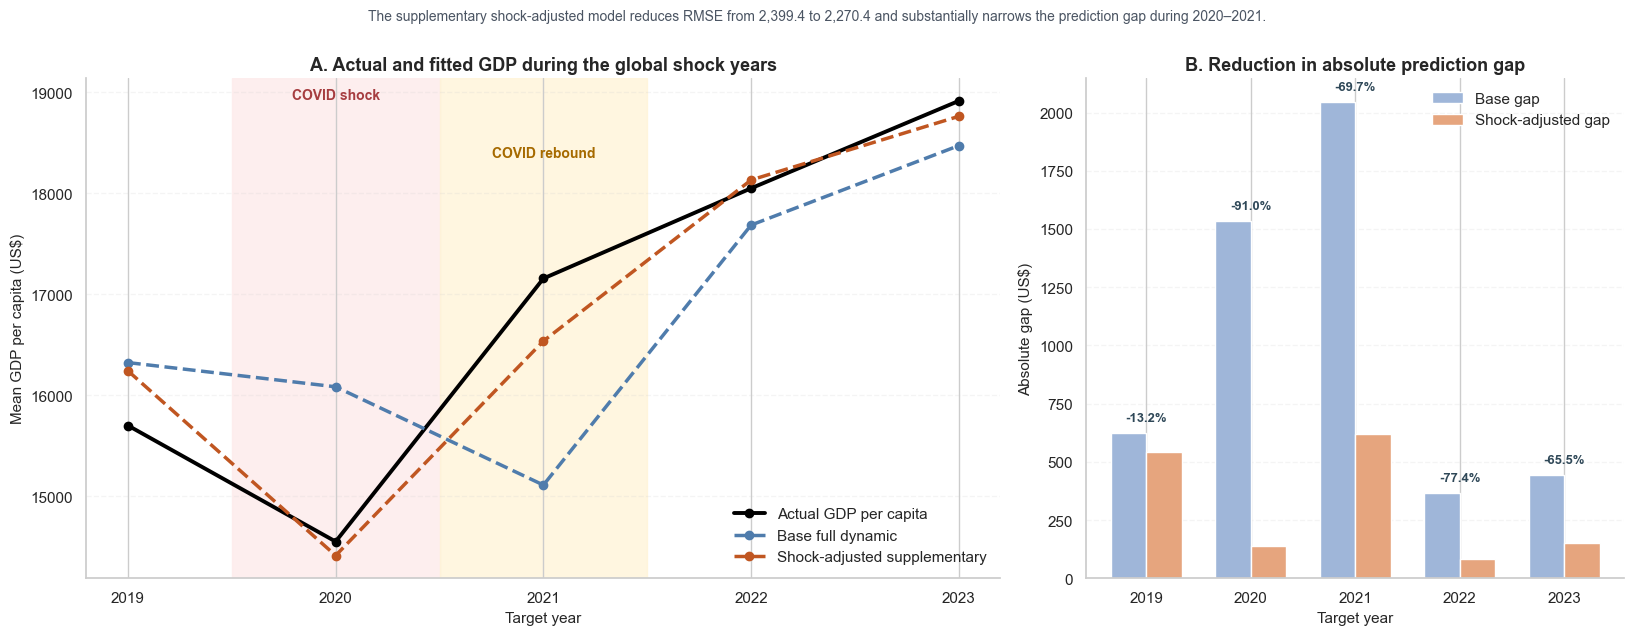

Saved: /Users/tonytony/Final Project/output/figures/figure_6_4_shock_robustness_check.png


,target_year,actual_mean_gdp,predicted_mean_gdp,mean_absolute_percentage_error_pct,model_label,absolute_gap_usd,pred_to_actual_ratio
0,2019,"15,698.9605","16,322.2820",5.2950,Base full dynamic,623.3215,1.0397
1,2020,"14,549.3612","16,082.2806",12.8234,Base full dynamic,"1,532.9194",1.1054
2,2021,"17,155.0981","15,109.1983",10.2731,Base full dynamic,"2,045.8998",0.8807
3,2022,"18,048.6179","17,684.3299",8.1097,Base full dynamic,364.2879,0.9798
4,2023,"18,914.0876","18,471.0834",7.5337,Base full dynamic,443.0042,0.9766
5,2019,"15,698.9605","16,240.2290",5.0016,Shock-adjusted supplementary,541.2685,1.0345
6,2020,"14,549.3612","14,411.3324",8.3718,Shock-adjusted supplementary,138.0288,0.9905
7,2021,"17,155.0981","16,535.5155",6.9781,Shock-adjusted supplementary,619.5826,0.9639
8,2022,"18,048.6179","18,130.7974",8.3153,Shock-adjusted supplementary,82.1796,1.0046
9,2023,"18,914.0876","18,761.2230",7.3633,Shock-adjusted supplementary,152.8647,0.9919


,target_year,base_gap_usd,shock_gap_usd,gap_reduction_usd,gap_reduction_pct
0,2019,623.3215,541.2685,82.0530,13.1638
1,2020,"1,532.9194",138.0288,"1,394.8906",90.9957
2,2021,"2,045.8998",619.5826,"1,426.3172",69.7159
3,2022,364.2879,82.1796,282.1083,77.4410
4,2023,443.0042,152.8647,290.1396,65.4936


,model_label,n_obs,AIC,BIC,MAE,RMSE,MAPE_pct,R_squared
0,Base full dynamic,4722,"-6,104.7829","-6,001.4231","1,006.7025","2,399.3517",8.7983,0.9830
1,Shock-adjusted supplementary,4722,"-6,320.1236","-6,190.9238",959.0168,"2,270.3584",8.5249,0.9848


In [ ]:
# Figure 6.4 — Shock-adjusted robustness check
# Panel A: Actual vs base full dynamic vs shock-adjusted supplementary
# Panel B: Error-gap reduction after adding explicit shock terms

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_DIR = BASE_DIR / "Data" / "Cleaned"
OUTPUT_DIR = BASE_DIR / "output" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YEARLY_COMPARE_PATH = DATA_DIR / "gdp_shock_robustness_expost_yearly_compare_2019_2023.csv"
GAP_REDUCTION_PATH = DATA_DIR / "gdp_shock_robustness_expost_gap_reduction.csv"
FIT_METRICS_PATH = DATA_DIR / "gdp_shock_robustness_expost_fit_metrics.csv"

yearly_df = pd.read_csv(YEARLY_COMPARE_PATH)
gap_df = pd.read_csv(GAP_REDUCTION_PATH)
fit_df = pd.read_csv(FIT_METRICS_PATH)

yearly_df["model_label"] = yearly_df["model_label"].astype(str).str.strip()

base_df = yearly_df[yearly_df["model_label"] == "Base full dynamic"].copy()
shock_df = yearly_df[yearly_df["model_label"] == "Shock-adjusted supplementary"].copy()

base_df = base_df.sort_values("target_year")
shock_df = shock_df.sort_values("target_year")
gap_df = gap_df.sort_values("target_year")

# use actual once from base_df
actual_years = base_df["target_year"].to_numpy()
actual_vals = base_df["actual_mean_gdp"].to_numpy()
base_pred = base_df["predicted_mean_gdp"].to_numpy()
shock_pred = shock_df["predicted_mean_gdp"].to_numpy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16.5, 6.8),
    gridspec_kw={"width_ratios": [1.7, 1.0]}
)

# ---------------------------------------
# Panel A — yearly path comparison
# ---------------------------------------
ax = axes[0]

ax.plot(
    actual_years,
    actual_vals,
    marker="o",
    linewidth=2.8,
    color="black",
    label="Actual GDP per capita"
)

ax.plot(
    base_df["target_year"],
    base_pred,
    marker="o",
    linestyle="--",
    linewidth=2.5,
    color="#4F7CAC",
    label="Base full dynamic"
)

ax.plot(
    shock_df["target_year"],
    shock_pred,
    marker="o",
    linestyle="--",
    linewidth=2.5,
    color="#C05621",
    label="Shock-adjusted supplementary"
)

# highlight main shock years
ax.axvspan(2019.5, 2020.5, color="#FDECEC", alpha=0.85, zorder=0)
ax.axvspan(2020.5, 2021.5, color="#FFF4D6", alpha=0.75, zorder=0)

ax.text(
    2020,
    ax.get_ylim()[1] * 0.995,
    "COVID shock",
    ha="center",
    va="top",
    fontsize=10,
    color="#A63D40",
    fontweight="bold"
)
ax.text(
    2021,
    ax.get_ylim()[1] * 0.965,
    "COVID rebound",
    ha="center",
    va="top",
    fontsize=10,
    color="#A66A00",
    fontweight="bold"
)

ax.set_title("A. Actual and fitted GDP during the global shock years", fontsize=13, fontweight="bold")
ax.set_xlabel("Target year", fontsize=11)
ax.set_ylabel("Mean GDP per capita (US$)", fontsize=11)
ax.set_xticks(actual_years)
ax.grid(axis="y", linestyle="--", alpha=0.20)
ax.legend(frameon=False, loc="lower right")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# ---------------------------------------
# Panel B — gap reduction
# ---------------------------------------
ax2 = axes[1]

bar_width = 0.34
x = np.arange(len(gap_df))

ax2.bar(
    x - bar_width / 2,
    gap_df["base_gap_usd"],
    width=bar_width,
    color="#9FB6D9",
    label="Base gap"
)

ax2.bar(
    x + bar_width / 2,
    gap_df["shock_gap_usd"],
    width=bar_width,
    color="#E6A57E",
    label="Shock-adjusted gap"
)

# annotate reduction %
for i, row in gap_df.iterrows():
    ax2.text(
        i,
        max(row["base_gap_usd"], row["shock_gap_usd"]) + 40,
        f"-{row['gap_reduction_pct']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9.4,
        color="#2F4858",
        fontweight="bold"
    )

ax2.set_title("B. Reduction in absolute prediction gap", fontsize=13, fontweight="bold")
ax2.set_xlabel("Target year", fontsize=11)
ax2.set_ylabel("Absolute gap (US$)", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(gap_df["target_year"].astype(int).tolist())
ax2.grid(axis="y", linestyle="--", alpha=0.20)
ax2.legend(frameon=False, loc="upper right")

for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

# ---------------------------------------
# Title and note
# ---------------------------------------
base_rmse = fit_df.loc[fit_df["model_label"] == "Base full dynamic", "RMSE"].iloc[0]
shock_rmse = fit_df.loc[fit_df["model_label"] == "Shock-adjusted supplementary", "RMSE"].iloc[0]

fig.text(
    0.5,
    0.952,
    f"The supplementary shock-adjusted model reduces RMSE from {base_rmse:,.1f} to {shock_rmse:,.1f} "
    "and substantially narrows the prediction gap during 2020–2021.",
    ha="center",
    va="center",
    fontsize=10,
    color="#4B5563"
)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])

save_path = OUTPUT_DIR / "figure_6_4_shock_robustness_check.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

display(yearly_df.round(4))
display(gap_df.round(4))
display(fit_df.round(4))

model_short,M1,M2,M3
wb_region_label,,,
East Asia & Pacific\n(n=111),"6,035.8600","6,015.5200","5,988.4800"
North America\n(n=10),"4,515.1500","4,721.2800","4,519.9500"
MENA + Afghanistan/Pakistan\n(n=102),"4,101.5700","4,097.7500","4,101.5000"
Europe & Central Asia\n(n=229),"3,869.9600","3,893.8300","3,891.2200"
Latin America & Caribbean \n(n=127),"1,690.6700","1,697.8000","1,704.6500"
South Asia\n(n=30),"1,065.1000","1,054.7200","1,050.4400"
Sub-Saharan Africa \n(n=204),438.6500,431.9700,418.5900


model_short,M1,M2,M3
wb_region_label,,,
East Asia & Pacific\n(n=111),8.9700,8.7000,8.6300
North America\n(n=10),6.5600,6.6400,6.4900
MENA + Afghanistan/Pakistan\n(n=102),13.3300,13.1000,12.6000
Europe & Central Asia\n(n=229),7.6300,7.6100,7.5900
Latin America & Caribbean \n(n=127),9.9400,9.9900,10.0000
South Asia\n(n=30),9.2000,9.0500,9.0700
Sub-Saharan Africa \n(n=204),8.5400,8.3800,8.0600


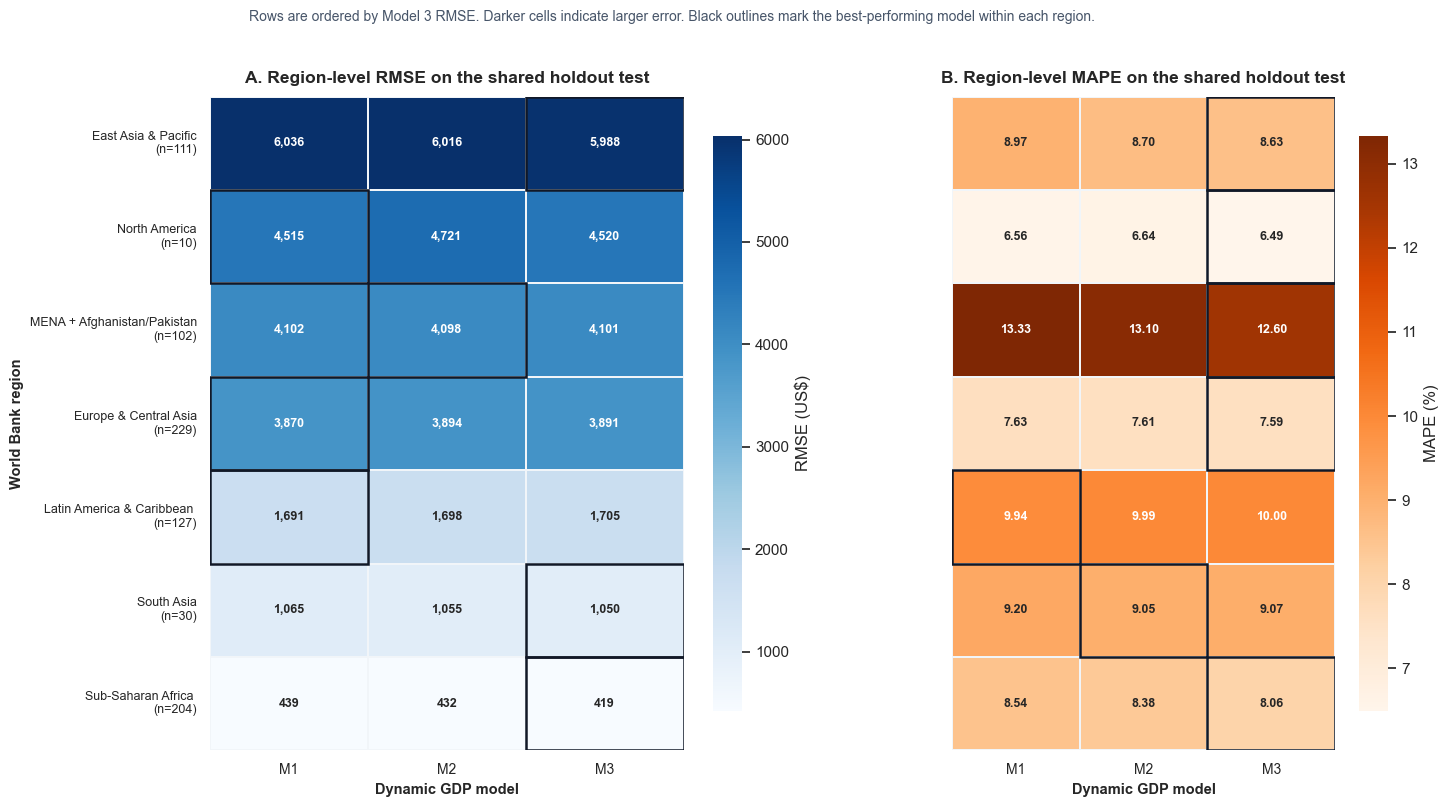

Saved: /Users/tonytony/Final Project/output/figures/figure_6_5_regional_error_heatmap_clean.png


In [ ]:
# Figure 6.5 — Regional error heterogeneity across the 3 dynamic GDP models
# Clean version: no overlap, shorter labels, more spacing

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sns.set_theme(style="white", font_scale=1.0)

BASE_DIR = Path("/Users/tonytony/Final Project")
REGION_METRICS_PATH = BASE_DIR / "Data" / "Cleaned" / "gdp_main_models_rebuilt_with_lag_region_metrics.csv"
OUTPUT_DIR = BASE_DIR / "output" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

region_df = pd.read_csv(REGION_METRICS_PATH)

model_label_map = {
    "Model 1 - Baseline Dynamic": "M1",
    "Model 2 - Extended Dynamic": "M2",
    "Model 3 - Full Dynamic": "M3",
}
model_order = ["M1", "M2", "M3"]

region_df["model_short"] = region_df["model"].map(model_label_map)

# Order rows by Model 3 RMSE: hardest region at the top
region_order = (
    region_df[region_df["model"] == "Model 3 - Full Dynamic"]
    .sort_values("RMSE", ascending=False)["wb_region"]
    .tolist()
)

nobs_lookup = region_df.groupby("wb_region")["n_obs"].max().to_dict()

# Shorter labels so the figure stays clean
short_region_map = {
    "East Asia & Pacific": "East Asia & Pacific",
    "North America": "North America",
    "Middle East, North Africa, Afghanistan & Pakistan": "MENA + Afghanistan/Pakistan",
    "Europe & Central Asia": "Europe & Central Asia",
    "Latin America & Caribbean": "Latin America & Caribbean",
    "South Asia": "South Asia",
    "Sub-Saharan Africa": "Sub-Saharan Africa",
}

region_label_map = {
    region: f"{short_region_map.get(region, region)}\n(n={int(nobs_lookup[region])})"
    for region in region_order
}

region_df["wb_region_label"] = region_df["wb_region"].map(region_label_map)

rmse_pivot = (
    region_df.pivot(index="wb_region_label", columns="model_short", values="RMSE")
    .reindex(index=[region_label_map[r] for r in region_order], columns=model_order)
)

mape_pivot = (
    region_df.pivot(index="wb_region_label", columns="model_short", values="MAPE_pct")
    .reindex(index=[region_label_map[r] for r in region_order], columns=model_order)
)

display(rmse_pivot.round(2))
display(mape_pivot.round(2))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16.5, 8.6),
    gridspec_kw={"width_ratios": [1.05, 0.85], "wspace": 0.28}
)

# Panel A: RMSE
sns.heatmap(
    rmse_pivot,
    ax=axes[0],
    cmap="Blues",
    annot=True,
    fmt=",.0f",
    linewidths=1.2,
    linecolor="#f1f5f9",
    cbar_kws={"label": "RMSE (US$)", "shrink": 0.88},
    annot_kws={"fontsize": 9, "fontweight": "bold"}
)
axes[0].set_title(
    "A. Region-level RMSE on the shared holdout test",
    fontsize=12.5,
    fontweight="bold",
    pad=10
)
axes[0].set_xlabel("Dynamic GDP model", fontsize=10.5, fontweight="bold")
axes[0].set_ylabel("World Bank region", fontsize=10.5, fontweight="bold")
axes[0].tick_params(axis="x", rotation=0, labelsize=10)
axes[0].tick_params(axis="y", rotation=0, labelsize=9)

# Outline best RMSE per row
for i, (_, row) in enumerate(rmse_pivot.iterrows()):
    best_j = int(np.nanargmin(row.values))
    axes[0].add_patch(
        Rectangle((best_j, i), 1, 1, fill=False, edgecolor="#111827", linewidth=1.8)
    )

# Panel B: MAPE
sns.heatmap(
    mape_pivot,
    ax=axes[1],
    cmap="Oranges",
    annot=True,
    fmt=".2f",
    linewidths=1.2,
    linecolor="#f1f5f9",
    cbar_kws={"label": "MAPE (%)", "shrink": 0.88},
    annot_kws={"fontsize": 9, "fontweight": "bold"}
)
axes[1].set_title(
    "B. Region-level MAPE on the shared holdout test",
    fontsize=12.5,
    fontweight="bold",
    pad=10
)
axes[1].set_xlabel("Dynamic GDP model", fontsize=10.5, fontweight="bold")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=0, labelsize=10)

# Hide duplicated y labels on the right panel
axes[1].set_yticklabels([])
axes[1].tick_params(axis="y", left=False)

# Outline best MAPE per row
for i, (_, row) in enumerate(mape_pivot.iterrows()):
    best_j = int(np.nanargmin(row.values))
    axes[1].add_patch(
        Rectangle((best_j, i), 1, 1, fill=False, edgecolor="#111827", linewidth=1.8)
    )

fig.text(
    0.5,
    0.948,
    "Rows are ordered by Model 3 RMSE. Darker cells indicate larger error. Black outlines mark the best-performing model within each region.",
    ha="center",
    fontsize=10,
    color="#475569"
)

# Clean spacing
plt.subplots_adjust(left=0.22, right=0.96, top=0.86, bottom=0.10, wspace=0.28)

save_path = OUTPUT_DIR / "figure_6_5_regional_error_heatmap_clean.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", save_path)

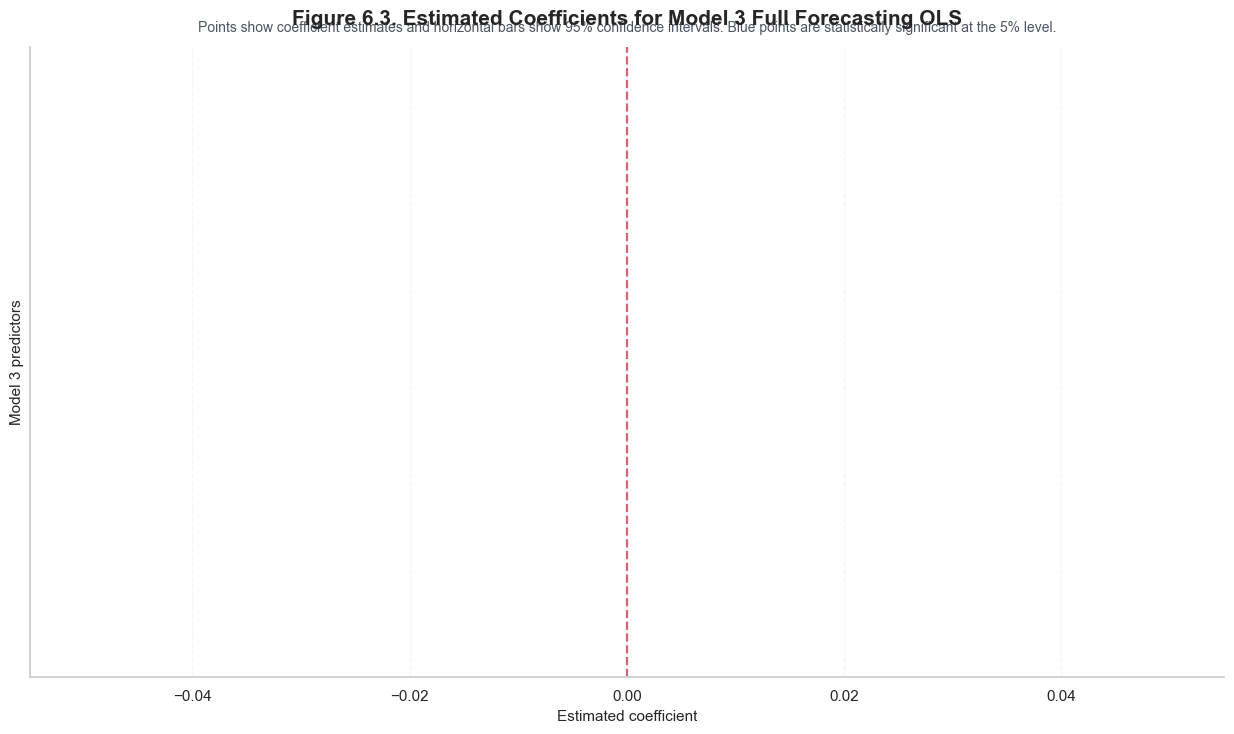

Saved: /Users/tonytony/Final Project/output/figures/figure_6_3_model_3_ols_coefficients.png


,term_label,coefficient,ci_lower,ci_upper,p_value


In [48]:
# Figure 6.3 — Coefficient plot for Model 3 Full Forecasting OLS
# Uses coefficient estimates and 95% confidence intervals
# Source file: gdp_main_models_coefficients.csv

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/tonytony/Final Project")
COEF_PATH = BASE_DIR / "Data" / "Cleaned" / "gdp_main_models_coefficients.csv"
OUTPUT_DIR = BASE_DIR / "output" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

coef_df = pd.read_csv(COEF_PATH)

TARGET_MODEL = "Model 3 - Full Forecasting Pooled OLS forecast model"

m3_df = coef_df[coef_df["model"] == TARGET_MODEL].copy()

# drop intercept for cleaner interpretation
m3_df = m3_df[m3_df["term"] != "Intercept"].copy()

# nicer display labels
label_map = {
    "log_population_total": "Log population",
    "life_expectancy_years": "Life expectancy",
    "inflation_pct_clean": "Inflation",
    "unemployment_pct_clean": "Unemployment",
    "internet_users_pct_clean": "Internet users",
    "year_trend": "Year trend",
    "global_financial_crisis": "Global financial crisis",
    "covid_shock": "COVID shock",
    "covid_rebound": "COVID rebound",
    "ukraine_energy_shock": "Ukraine / energy shock",
    "C(wb_region)[T.Europe & Central Asia]": "Region: Europe & Central Asia",
    "C(wb_region)[T.Latin America & Caribbean ]": "Region: Latin America & Caribbean",
    "C(wb_region)[T.Middle East, North Africa, Afghanistan & Pakistan]": "Region: MENA / Afghanistan / Pakistan",
    "C(wb_region)[T.North America]": "Region: North America",
    "C(wb_region)[T.South Asia]": "Region: South Asia",
    "C(wb_region)[T.Sub-Saharan Africa ]": "Region: Sub-Saharan Africa",
}

m3_df["term_label"] = m3_df["term"].map(lambda x: label_map.get(x, x))

# order by coefficient size for readability
m3_df = m3_df.sort_values("coefficient").reset_index(drop=True)

# significance colouring
m3_df["significant"] = m3_df["p_value"] < 0.05
m3_df["point_color"] = np.where(m3_df["significant"], "#355C7D", "#B0B7C3")

fig, ax = plt.subplots(figsize=(12.5, 7.5))

y_pos = np.arange(len(m3_df))

# confidence intervals
for i, row in m3_df.iterrows():
    ax.hlines(
        y=i,
        xmin=row["ci_lower"],
        xmax=row["ci_upper"],
        color="#9AA5B1",
        linewidth=2.2,
        zorder=1
    )

# point estimates
ax.scatter(
    m3_df["coefficient"],
    y_pos,
    s=70,
    color=m3_df["point_color"],
    edgecolor="white",
    linewidth=1.0,
    zorder=3
)

# reference line at zero
ax.axvline(0, color="#D1495B", linestyle="--", linewidth=1.6, alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(m3_df["term_label"], fontsize=10)
ax.set_xlabel("Estimated coefficient", fontsize=11)
ax.set_ylabel("Model 3 predictors", fontsize=11)

ax.set_title(
    "Figure 6.3. Estimated Coefficients for Model 3 Full Forecasting OLS",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.text(
    0.5,
    1.02,
    "Points show coefficient estimates and horizontal bars show 95% confidence intervals. "
    "Blue points are statistically significant at the 5% level.",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#4B5563"
)

ax.grid(axis="x", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

save_path = OUTPUT_DIR / "figure_6_3_model_3_ols_coefficients.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

display(
    m3_df[
        ["term_label", "coefficient", "ci_lower", "ci_upper", "p_value"]
    ].round(4)
)